# ML from DFT data

- [ ] learn on separated FM and NM AGAIN
- [ ] remove high order BOP features before learing
- [X] Recursive Feature elimination after removing high order features
- [ ] make recursion on bond energy
- [X] change OS to 1/10,
- [X] 1/10 OS and scf bop
- [ ] scaled bond integrals
- learn form library features
- compare different regression methods
   - Linear regression
   - add SVM
   - kernel methods
   - Gaussian process.
- compare different test-train splittings
- Learn on increasing domain knowledge

 - input: clean features dataframes from pickles
 - output : plots and Models

In [1]:
from Tools.DatasetTools.Commoms import *
from Tools.DatasetTools.DatasetOperator import Dataset, DatasetTester

In [2]:
from Tools.DatasetTools.Tools import get_str_formatted
from sklearn.model_selection import StratifiedKFold

In [3]:
import matplotlib
from matplotlib.ticker import FormatStrFormatter

# Parameters 

In [4]:
target_case = 'EF_nmhcp'

In [5]:
DS = Dataset('Fe-Mo', target_name=target_case, remove_phases_query='Phase != "bcc" and Phase != "fcc" and Phase !="hcp"')

Possible models are: **Kernel Ridge, MLP and Random Forest**

In [6]:
ModelName = 'Random Forest'

In [7]:
namefile = ModelName.replace(' ', '')

In [8]:
suffix = f"no_hcp_bcc_fcc_{namefile}" #'CV_restart_folds_inloop''CV_restart_folds_inloop

In [9]:
(DS.BS.Phase == 'hcp').sum()

0

# Targets

In [10]:
plt.rc('text', usetex=False)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


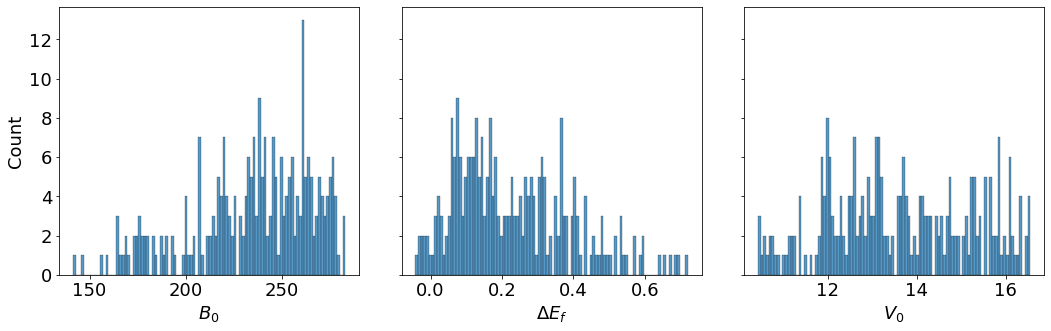

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0], bins=100)
sns.histplot( DS.BS[target_case], ax= ax[1], bins=100)
sns.histplot( DS.BS['V0'], ax= ax[2], bins = 100)
ax[0].set_xlabel('$B_0$')
ax[1].set_xlabel(r'$\Delta E_f$')
ax[2].set_xlabel('$V_0$')
fig.tight_layout()
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_target_distributions_{target_case}.eps')

In [12]:
DS.BS.B0.idxmax()

'Fe_pv4Mo_sv2.C15-A2B.NM'

In [13]:
DS.BS.query('B0 < 150')

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv29.chi.FM,bulk chi.FM,12.050793 A,-8.137580,152.259441 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,29,0,29,1.0,0.0,FM,chi,0.117648,0.117648,0.117648
Fe_pv6.C15.FM,bulk C15.FM,12.092153 A,-8.111059,148.116428 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.021,0,1,...,6,0,6,1.0,0.0,FM,C15,0.144169,0.144169,0.144169


# Machine Learning 

In [14]:
from Tools.DatasetTools.MLConveniences import *

In [15]:
resultslocation = DS.resultslocation

## Feature sets

In [16]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [17]:
for name, featuredf in Features.items():
    if 'ACE' in name:
        print (name )

ACE
NOZERO-ACE
NOZERO_NOONE-ACE
NOZERO_NOONE_NOTWO-ACE
NOTHREE-ACE
NOTHREE-NOTWO-ACE
NOTHREE-NOTWO_NOONE-ACE
Canonical ACE
ACE no CNAV
NOZERO-ACE no CNAV
NOZERO_NOONE-ACE no CNAV
NOZERO_NOONE_NOTWO-ACE no CNAV
NOTHREE-ACE no CNAV
NOTHREE-NOTWO-ACE no CNAV
NOTHREE-NOTWO_NOONE-ACE no CNAV
Canonical ACE no CNAV


In [18]:
Features['NOTHREE-ACE']

,Structure,Mag,light_ace_projections_0_0,light_ace_projections_0_CN12,light_ace_projections_0_CN13,light_ace_projections_0_CN14,light_ace_projections_0_CN15,light_ace_projections_0_CN16,light_ace_projections_1_0,light_ace_projections_1_CN12,...,light_ace_projections_277_CN14,light_ace_projections_277_CN15,light_ace_projections_277_CN16,light_ace_projections_278_0,light_ace_projections_278_CN12,light_ace_projections_278_CN13,light_ace_projections_278_CN14,light_ace_projections_278_CN15,light_ace_projections_278_CN16,random
Fe_pv4Mo_sv20.C36-ABBBB.FM,3,1,0.700782,0.519960,0.0,0.000000,0.000000,0.180822,0.740542,0.492038,...,0.000000,0.000000,31.343937,539.53020,315.38065,0.0,0.000000,0.000000,224.149600,0.315527
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,4,0,1.227271,0.573550,0.0,0.277732,0.146631,0.229359,1.211142,0.612540,...,26.184114,13.263720,14.413171,314.19864,187.35700,0.0,66.610390,31.580824,28.650434,0.530406
Fe_pv2Mo_sv11.mu-BBABB.FM,9,1,0.619778,0.311880,0.0,0.155909,0.121008,0.030980,0.676809,0.351540,...,14.082514,13.368032,9.052814,638.64246,354.83344,0.0,42.839725,55.100155,185.869140,0.214454
Fe_pv8Mo_sv22.sigma-BBBAB.NM,10,0,1.153250,0.300465,0.0,0.685557,0.167228,0.000000,1.148779,0.398667,...,58.701120,15.163990,0.000000,335.94230,159.65913,0.0,138.973790,37.309370,0.000000,0.117183
Fe_pv2Mo_sv11.mu-BBBBA.NM,9,0,0.630194,0.345619,0.0,0.063364,0.155909,0.065302,0.663000,0.350802,...,11.676299,12.885588,15.284929,602.71690,319.07614,0.0,104.451940,38.337760,140.851060,0.122451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv8Mo_sv16.C36-BAABB.NM,3,0,1.473401,1.008198,0.0,0.000000,0.000000,0.465202,1.482305,0.968531,...,0.000000,0.000000,39.042336,235.06946,147.26814,0.0,0.000000,0.000000,87.801315,0.963811
Fe_pv30.sigma.FM,10,1,5.559784,1.852193,0.0,2.965189,0.742403,0.000000,5.308828,1.752612,...,0.000000,0.000000,0.000000,0.00000,0.00000,0.0,0.000000,0.000000,0.000000,0.277129
Fe_pv6.C15.FM,2,1,5.557653,3.706728,0.0,0.000000,0.000000,1.850925,5.295891,3.544942,...,0.000000,0.000000,0.000000,0.00000,0.00000,0.0,0.000000,0.000000,0.000000,0.989515
Mo_sv8.A15.NM,0,0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1019.02940,255.01729,0.0,764.012100,0.000000,0.000000,0.830080


In [19]:
Features['NOTHREE-ACE no CNAV'].shape

(262, 282)

## BOP features with and without CP averages

In [20]:
# Features.update({name+' no Zeros': clean_zeros(name, features) for name, features in Features.items() if notyetclean(name)} )

## test - train splits

In [21]:
samplesplit = DS.get_samplesplit()

<AxesSubplot:xlabel='Phase', ylabel='Count'>

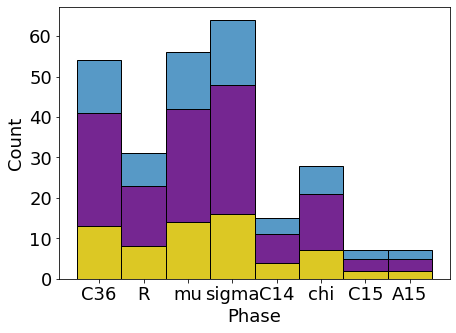

In [22]:
ax = sns.histplot(DS.StructureNames)
sns.histplot(DS.StructureNames.loc[samplesplit['train']], ax = ax, color = 'purple')
sns.histplot(DS.StructureNames.loc[samplesplit['test']], ax = ax, color = 'yellow')

# Models: adjust params

In [23]:
import warnings
warnings.simplefilter('ignore')

In [24]:
Models = {
    'Kernel Ridge': Pipeline([('scaler', StandardScaler()), ('regressor', KernelRidge())]),
    'MLP': Pipeline([('scaler', StandardScaler()), ('regressor', MLPRegressor())]),
    'Random Forest': Pipeline([('regressor', RandomForestRegressor())]),
    'Gaussian Process': Pipeline([('regressor', GaussianProcessRegressor())])
}

In [25]:
from importlib.machinery import SourceFileLoader
MO = SourceFileLoader('MO', 'Tools/DatasetTools/ModelSelection.py').load_module().ModelOptions(DS.dataset)

In [26]:
MO.load_model_options(ModelName)

In [27]:
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, RationalQuadratic, ConstantKernel, ExpSineSquared, DotProduct, Product

##  Features

In [28]:
DS.BS.index[DS.BS.index.str.contains('bcc')]

Index([], dtype='object')

In [29]:
test_bop_feature = '0.7dProjections 0.5OS BOP'

In [30]:
Features[test_bop_feature].index[Features[test_bop_feature].index.str.contains('bcc')]

Index([], dtype='object')

In [31]:
Features[test_bop_feature].index[Features[test_bop_feature].index.str.contains('bcc')]

Index([], dtype='object')

In [32]:
DS.target.index.difference(Features[test_bop_feature].index)

Index([], dtype='object')

In [33]:
for name, thefeatures in Features.items():
    print(name, thefeatures.shape)

atomic (262, 135)
dataset (262, 32)
SOAP_canonicalW (262, 1893)
SOAP_specific (262, 7185)
Pyscal (262, 15)
ACE (262, 1803)
NOZERO-ACE (262, 777)
NOZERO_NOONE-ACE (262, 375)
NOZERO_NOONE_NOTWO-ACE (262, 375)
NOTHREE-ACE (262, 1677)
NOTHREE-NOTWO-ACE (262, 951)
NOTHREE-NOTWO_NOONE-ACE (262, 495)
Canonical ACE (262, 417)
Canonical BOP (262, 405)
0.7dProjections 0.5OS BOP (262, 417)
0.7spProjections 0.5OS BOP (262, 429)
dataset + Canonical BOP (262, 434)
dataset + 0.7dProjections 0.5OS BOP (262, 446)
dataset + 0.7spProjections 0.5OS BOP (262, 458)
atomic no CNAV (262, 135)
dataset no CNAV (262, 17)
SOAP_canonicalW no CNAV (262, 318)
SOAP_specific no CNAV (262, 1200)
Pyscal no CNAV (262, 5)
ACE no CNAV (262, 303)
NOZERO-ACE no CNAV (262, 132)
NOZERO_NOONE-ACE no CNAV (262, 65)
NOZERO_NOONE_NOTWO-ACE no CNAV (262, 65)
NOTHREE-ACE no CNAV (262, 282)
NOTHREE-NOTWO-ACE no CNAV (262, 161)
NOTHREE-NOTWO_NOONE-ACE no CNAV (262, 85)
Canonical ACE no CNAV (262, 72)
Canonical BOP no CNAV (262, 70)
0.

In [34]:
Features[test_bop_feature].index[Features[test_bop_feature].index.str.contains('bcc')]

Index([], dtype='object')

# Feature Selection

In [35]:
suffix

'no_hcp_bcc_fcc_RandomForest'

In [36]:
feature_concat_resul_loc = os.path.join(DS.dataset, 'results', f'concatenation_results_{target_case}_{suffix}.pkl')  
if os.path.exists(feature_concat_resul_loc):
    with open(feature_concat_resul_loc, 'rb') as pkl:
        savedFCresults = pickle.load(pkl)
else:
    savedFCresults = {}

In [37]:
FCresults = {}

In [38]:
for combi, selectionloop in savedFCresults.items():
    print (combi)
    FCresults[combi] = []
    for thisloop in selectionloop:
        badnews =  'random' in thisloop.index
        if badnews:
            print(badnews, thisloop.index.get_loc('random'),'/', len (thisloop))
            thisloop=thisloop.loc[:'random'].iloc[:-1]
        else:
            print (badnews)
            FCresults[combi].append(thisloop)
        if len(thisloop) < 1:
            continue

('RandomForest', 'SOAP_canonicalW')
('RandomForest', '0.7dProjections 0.5OS BOP')
False
('RandomForest', '0.7spProjections 0.5OS BOP')
False
('Random Forest', 'atomic')
False
False
('Random Forest', 'dataset')
False
False
('Random Forest', 'Canonical ACE')
False
False
('Random Forest', 'Canonical BOP')
False
False
False
('Random Forest', 'SOAP_canonicalW')
False
False
False
('Random Forest', '0.7dProjections 0.5OS BOP')
False
False
('Random Forest', '0.7spProjections 0.5OS BOP')
False
False
False
('Random Forest', 'ACE no CNAV')
False
('Random Forest', 'ACE')
False
False
False
False


In [39]:
for combi, selectionloop in FCresults.items():
    print (combi)
    for thisloop in selectionloop:
        badnews =  'random' in thisloop.index
        if badnews:
            print(badnews, thisloop.index.get_loc('random'),'/', len (thisloop))
        else:
            print (badnews)

('RandomForest', 'SOAP_canonicalW')
('RandomForest', '0.7dProjections 0.5OS BOP')
False
('RandomForest', '0.7spProjections 0.5OS BOP')
False
('Random Forest', 'atomic')
False
False
('Random Forest', 'dataset')
False
False
('Random Forest', 'Canonical ACE')
False
False
('Random Forest', 'Canonical BOP')
False
False
False
('Random Forest', 'SOAP_canonicalW')
False
False
False
('Random Forest', '0.7dProjections 0.5OS BOP')
False
False
('Random Forest', '0.7spProjections 0.5OS BOP')
False
False
False
('Random Forest', 'ACE no CNAV')
False
('Random Forest', 'ACE')
False
False
False
False


In [40]:
with open(feature_concat_resul_loc, 'wb') as pkl:
    pickle.dump(FCresults,pkl)

In [41]:
nowantoplot = [''] # ['0.6dProjections OS BOP','0.8 Projections OS BOP', 'Projections OS BOP', 'atomic no CNAV', 'dataset no CNAV', 'SOAP_canonicalFe']

In [42]:
iwanttoplot = [combi[1] for combi in FCresults.keys() if combi[0] == ModelName and combi[1] not in nowantoplot and len(FCresults[combi])>0]# and 'no CNAV' not in combi[1] and combi[1] != 'ACE']

In [43]:
for featurename in iwanttoplot:
    print(featurename, len(FCresults[(ModelName, featurename)]))

atomic 2
dataset 2
Canonical ACE 2
Canonical BOP 3
SOAP_canonicalW 3
0.7dProjections 0.5OS BOP 2
0.7spProjections 0.5OS BOP 3
ACE no CNAV 1
ACE 4


In [44]:
iwanttoplot

['atomic',
 'dataset',
 'Canonical ACE',
 'Canonical BOP',
 'SOAP_canonicalW',
 '0.7dProjections 0.5OS BOP',
 '0.7spProjections 0.5OS BOP',
 'ACE no CNAV',
 'ACE']

In [45]:
pallete = sns.color_palette(n_colors=len(iwanttoplot))

In [46]:
colors = {name: c for name, c in zip(iwanttoplot, pallete)}

In [47]:
# iwanttoplot = ['atomic', 'dataset', 'Canonical BOP', 'dataset + Canonical BOP', 'Projections BOP', 'dataset + Projections BOP', 'Projections sOS BOP', 'dataset + Projections sOS BOP' ]
#iwanttoplot = ['ACE','SOAP_specific',  'Canonical BOP', 
#iwanttoplot = ['Projections OS BOP']#, 'Projections sOS BOP']#, 'SOAP_canonicalW',

In [48]:
folder = StratifiedKFold(shuffle=True)
folds_generator = folder.split(DS.samplesplit['train'], DS.StructureNames[DS.samplesplit['train']])
train_folds = list(folds_generator)
TestCV = GridSearchCV(Models[ModelName], MO.modeloptions[ModelName], cv = train_folds, return_train_score=True)

In [49]:
FittedGS = {}

In [50]:
MO.modeloptions

{'Random Forest': {'regressor__max_depth': [5, 10],
  'regressor__min_samples_split': [2],
  'regressor__min_samples_leaf': [1, 10],
  'regressor__max_leaf_nodes': [None, 20, 30]}}

# DS.Features.keys(): #['Canonical BOP']:
for featurename in iwanttoplot: #FittedModels.items():
    print(featurename)
    if 'random' not in Features[featurename]:
        Features[featurename]['random'] = np.random.rand(DS.target.shape[0])
    corrs = pd.concat([Features[featurename], DS.target], axis=1).corr().abs()[target_case]
    
    reasonable_features = corrs[corrs > corrs['random']].index.difference([target_case])
    combi = (ModelName, featurename)
#   model = copy.deepcopy(fmodel.best_estimator_)
    if len(FCresults[combi]) >= 1 :
        continue
    FittedGS[combi] = copy.deepcopy(TestCV)
    FC = FeatureConcatenate(DS, FittedGS[combi],  MO.modeloptions[ModelName]) #fmodel.best_params_,)model_params_grid =
    FCresults[combi].append (FC.get_best_features_list(combi[1], num_features = 2, max_workers=3, search_only = reasonable_features))#DS.Features[combi[1]].shape[1]
    with open(feature_concat_resul_loc, 'wb') as pkl:
        pickle.dump(FCresults, pkl)

In [51]:
#with open(feature_concat_resul_loc, 'wb') as pkl:
#    pickle.dump(FCresults, pkl)

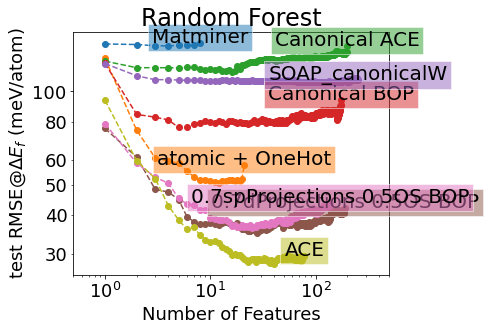

In [52]:
from matplotlib.ticker import FormatStrFormatter
fig, axes = plt.subplots()
for combi, result in FCresults.items():
    if len(result) < 1:
        continue
    if combi[0] != ModelName:
        continue
    if combi[1] not in iwanttoplot:
        continue
    if 'no CNAV' in combi[1]:
        continue
#    if ' OS ' in combi[1]:
#        continue
    nfeats = result[-1].shape[0]
    x=np.linspace(1,nfeats, nfeats)
    legend = combi[1].replace('dataset', 'polyhedra')
    legend = legend.replace('atomic', 'Matminer')\
        .replace('_specific','').replace('0.7 ','')\
        .replace('polyhedra','atomic + OneHot')\
        .replace('Projections OS BOP', 'Bond Specific BOP')
    if 'test' not in result[-1].keys():
        continue
    y = result[-1]['test']*1000
    axes.plot(x, y ,'--o',c=colors[combi[1]], label=legend)
    text = axes.text(x[-1], y[-1], legend, horizontalalignment='center')#, backgroundcolor='white', alpha=0.5)
    text.set_bbox(dict(facecolor=colors[combi[1]], alpha=0.5,edgecolor='white'))
axes.set_xscale('log')
axes.set_ylabel(r'test RMSE@$\Delta E_f$ (meV/atom)')
axes.set_xlabel('Number of Features')
axes.tick_params(axis='y', which='minor')
axes.set_yscale('log', subs = [0.2, 0.3, 0.4,0.5, 0.6, 0.8])
axes.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
axes.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
#plt.legend(bbox_to_anchor=(0.6,0.5))
axes.set_xlim([0.5, 0.5e3])
axes.set_title(ModelName)
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves_{target_case}_{nameforfile}.pdf')

In [53]:
'Mag' in FCresults[(ModelName, test_bop_feature )][-1].index

True

In [54]:
combi = (ModelName, test_bop_feature)
selected_pos = FCresults[combi][-1].index[0]
y_pos = FCresults[combi][-1]['test']*1000
x = np.linspace(1, len(y_pos), len(y_pos))
axes.annotate(get_str_formatted(selected_pos), (x[0], y_pos[0]-5), xytext=(x[0]-0.1, y_pos[0]-40), arrowprops={'facecolor':'black'})
selected_next = FCresults[combi][-1].index[1]
axes.annotate(get_str_formatted(selected_next), (x[1], y_pos[1]), xytext=(x[1]*2, y_pos[1]+20), arrowprops={'facecolor':'black'})
ymag = y_pos[y_pos.index=='Mag']['Mag']
xmag = x[y_pos.index=='Mag']
axes.annotate('Mag', (xmag-0.1, ymag-1), xytext=(xmag/5, ymag-10), arrowprops={'facecolor':'black'})
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves_annotated_{target_case}_CV.pdf')

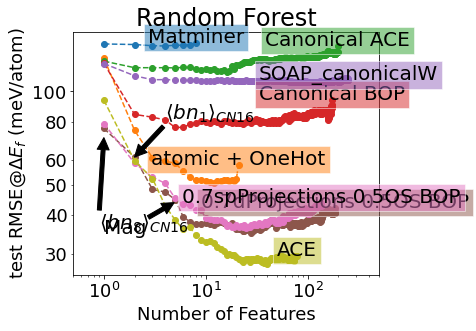

In [55]:
fig

## Feature Selection

In [56]:
iwanttoplot_all = [feature for feature in iwanttoplot if 'no CNAV' not in feature and 'dataset' not in feature and 'atomic' in feature]

In [57]:
iwanttoplot_all = {'dataset': 'atomic + OneHot', test_bop_feature: 'BOP',  'ACE':'ACE', 'Canonical BOP': 'Canonical BOP'}#'SOAP_specific': 'SOAP',

In [58]:
from matplotlib import __version__

In [59]:
def plot_panel_learning_curves(feature_list: dict):# -> list[matplotlib.axes._subplots.Axes]: 
    nplots = len(feature_list)
    width = plt.rcParams['figure.figsize'][0]*(3/5)*nplots
    height = plt.rcParams['figure.figsize'][1]
    fig, axes = plt.subplots(1,nplots, figsize=(width, height), sharey = True)# figsize=(width, 5*width/13),
    for (featurename, featurelabel), ax in zip(feature_list.items(), axes):
        combi = (ModelName, featurename)
        ax.set_title(featurelabel)
        results = FCresults[combi]
        for j, result in enumerate(results):
            x = np.linspace(1, result.shape[0], result.shape[0])
            if 'test' not in result.keys():
                continue
            sns.scatterplot(x=x, y=result['test']*1000, ax=ax)
        N = Features[featurename].shape[1]
        NL = len(results)
        ax.legend([],[],title=f'N = {N}\n NL = {NL}')
        ax.set_yscale('log', subs=[2, 6, 10])
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
#    ax.set_ylim([19, 110])
    ax.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
    ax.tick_params(axis='y', which = 'minor')
    axes[0].set_xticks([1, 5, 10])
    axes[0].set_ylabel(r'test RMSE @$\Delta E_f$ (meV/at)')
    fig.supxlabel('Number of features')
    return fig, axes
#    axes[i-1].set_xticklabels('')
#axes[0].yaxis.set_major_formatter(FormatStrFormatter("%.0e"))

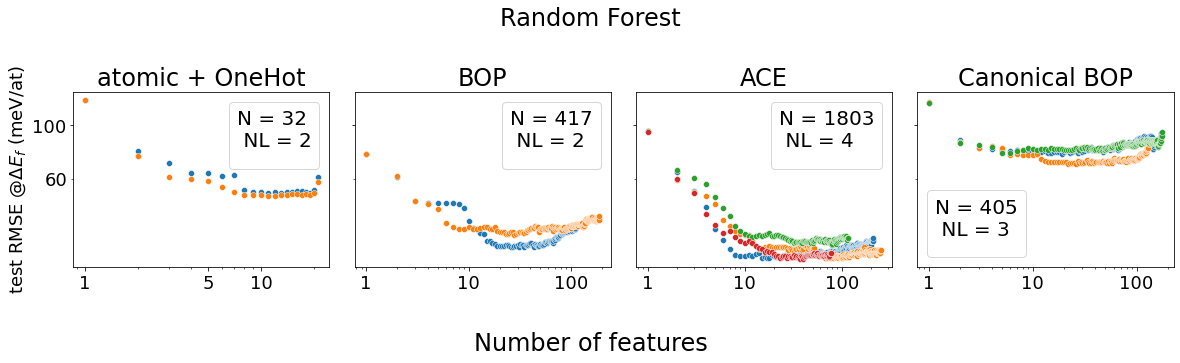

In [60]:
fig, axes = plot_panel_learning_curves(iwanttoplot_all)
nameinfile = ModelName.replace(' ','')
fig.suptitle(ModelName)
fig.tight_layout()
fig.savefig(os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_{nameinfile}_learning_curves_tovote.pdf'))

# Feature transformers

In [61]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import RegressorMixin

In [62]:
def get_optimal_feature_score(FeatureScoreData:pd.core.frame.DataFrame):
    thisatmin = FeatureScoreData['test'].argmin()
    return FeatureScoreData[:thisatmin]

In [63]:
def get_optimal_features(FeatureScoreData:pd.core.frame.DataFrame):
    thisatmin = FeatureScoreData['test'].argmin()
    return FeatureScoreData.index[:thisatmin]

In [64]:
def filter_features (Features_DF: pd.core.frame.DataFrame, learning_curve = pd.core.frame.DataFrame):
    if 'params' not in learning_curve.columns:
        raise ValueError('the learning curve provided is not an evaluation of best features')
    columns = get_optimal_features(learning_curve)
    return Features_DF[columns]

def get_optimal_feature_names(Features_DF: pd.core.frame.DataFrame, learning_curve = pd.core.frame.DataFrame):
    columns = get_optimimal_features(learning_curve)
    return columns

In [65]:
class AverageEnsambleRegressor():
    def __init__(self, named_estimators = list[tuple[str, RegressorMixin]]):
        self.named_estimators_ : list[tuple[str, RegressorMixin]] = named_estimators

    def fit(self, _X : pd.core.frame.DataFrame , _Y : pd.core.series.Series) -> pd.core.series.Series:

        for name, estimator in self.named_estimators_:
            estimator.fit(_X, _Y)

    def predict(self, _X : pd.core.frame.DataFrame) -> pd.core.series.Series:

        self.predictions_ = pd.concat(
            [pd.Series(estimator.predict(_X), name=name, index=_X.index) for name, estimator in self.named_estimators_],
            axis=1
        )

        return self.predictions_.mean(axis=1)

    def get_prediction_std(self):
        if not hasattr(self, 'predictions_'):
            pdb.set_trace()
            raise NameError('you must fit the models first')

        err = self.predictions_.std(axis=1)
        return err

In [66]:
combi = (ModelName, test_bop_feature)

In [67]:
RegresorsBag = {}

In [68]:
from sklearn.ensemble import VotingRegressor

In [69]:
VotedScores = {}
AveragedScores = {}

In [70]:
voting_regressor = {}
average_regressor = {}
indexedregressorbag = {}

## Voting Regressor based on regressor bag

In [71]:
for combi, LearningCurveList in FCresults.items():
    RegresorsBag[combi] = []
    if combi[1] not in Features.keys():
        continue
    if combi[0] != ModelName:
        continue
    if len(LearningCurveList) < 1:
        continue
    for LearningCurve in LearningCurveList:
        if len(LearningCurve) < 1:
            continue
        transformer = FunctionTransformer(
            filter_features, kw_args = {'learning_curve' : LearningCurve}, 
        )
        RegresorsBag[combi].append(copy.deepcopy(Models[ModelName])) 
        RegresorsBag[combi][-1].steps.insert(0, ['feature_selection', transformer])
        thiscurve = LearningCurve
        RegresorsBag[combi][-1].set_params(**thiscurve.params.iloc[-1])
    
    indexedregressorbag[combi] = [(str(i), thisregressor) for i, thisregressor in enumerate(RegresorsBag[combi])]
    if len(indexedregressorbag) < 1:
        continue

    voting_regressor[combi] = VotingRegressor(indexedregressorbag[combi])
    voting_regressor[combi].fit(Features[combi[1]].loc[DS.samplesplit['train']], DS.target.loc[DS.samplesplit['train']])


    VotedScores[combi] = score_fitted_model(
        voting_regressor[combi], 
        Features[combi[1]].loc[DS.samplesplit['train']],
        Features[combi[1]].loc[DS.samplesplit['test']],
        DS.target[DS.samplesplit['train']],
        DS.target[DS.samplesplit['test']])

In [72]:
for combi, votingregressor in voting_regressor.items():
    for index, pipeline in votingregressor.estimators:
        learning_curve = pipeline.named_steps['feature_selection'].kw_args['learning_curve']
        print(combi, len(learning_curve))


('Random Forest', 'atomic') 8
('Random Forest', 'atomic') 8
('Random Forest', 'dataset') 21
('Random Forest', 'dataset') 21
('Random Forest', 'Canonical ACE') 197
('Random Forest', 'Canonical ACE') 198
('Random Forest', 'Canonical BOP') 172
('Random Forest', 'Canonical BOP') 130
('Random Forest', 'Canonical BOP') 175
('Random Forest', 'SOAP_canonicalW') 251
('Random Forest', 'SOAP_canonicalW') 251
('Random Forest', 'SOAP_canonicalW') 251
('Random Forest', '0.7dProjections 0.5OS BOP') 110
('Random Forest', '0.7dProjections 0.5OS BOP') 188
('Random Forest', '0.7spProjections 0.5OS BOP') 101
('Random Forest', '0.7spProjections 0.5OS BOP') 100
('Random Forest', '0.7spProjections 0.5OS BOP') 137
('Random Forest', 'ACE no CNAV') 173
('Random Forest', 'ACE') 211
('Random Forest', 'ACE') 251
('Random Forest', 'ACE') 116
('Random Forest', 'ACE') 78


# SAVE THE REGRESSOR!

In [73]:
VotingRegressor

sklearn.ensemble._voting.VotingRegressor

In [74]:
regresorbag_file =os.path.join(DS.dataset, 'results', f'regressors_bag_{nameforfile}.pkl')

In [75]:
indexedbags_file = os.path.join(DS.dataset, 'results', f'indexed_bag_{nameforfile}.pkl')

In [76]:
regressor_file = os.path.join(DS.dataset, 'results', f'voting_regressor_{nameforfile}.pkl')

In [77]:
import joblib

In [78]:
joblib.dump(RegresorsBag, regresorbag_file)
joblib.dump(indexedregressorbag, indexedbags_file)
joblib.dump(voting_regressor, regressor_file)

['Fe-Mo/results/voting_regressor_RandomForest.pkl']

In [79]:
voting_regressor = joblib.load(regressor_file)

In [80]:
os.path.exists(regressor_file)

True

In [81]:
err_test = {}
for (featurename, featuretag), ax in zip(iwanttoplot_all.items(), axes):
    ax.grid('on')
    if featurename not in Features.keys():
        continue
    combi = (ModelName, featurename)
    if combi not in voting_regressor.keys():
        continue
    bagging_regressor = voting_regressor[combi]
    err_test[featurename] = (bagging_regressor.predict(Features[featurename].loc[DS.samplesplit['test']]) - DS.target[DS.samplesplit['test']]).abs()

In [82]:
min_err_test =min( [  err.min() for err in err_test.values() ] )

In [83]:
min_err_test

1.179248737387395e-05

In [84]:
max_err_test =min( [  err.max() for err in err_test.values() ] )

In [85]:
max_err_test

0.08744492011697191

In [86]:
logbins = np.logspace(np.log10(min_err_test*1000), np.log10(max_err_test*1000), 10)

In [87]:
VotedScores

{('Random Forest', 'atomic'): {'test': 0.13838926636571414,
  'train': 0.08865357239582246},
 ('Random Forest', 'dataset'): {'test': 0.05313798543420853,
  'train': 0.02711328625981573},
 ('Random Forest', 'Canonical ACE'): {'test': 0.11830946394871629,
  'train': 0.11324296708946571},
 ('Random Forest', 'Canonical BOP'): {'test': 0.07647932980542196,
  'train': 0.043058868300451254},
 ('Random Forest', 'SOAP_canonicalW'): {'test': 0.10655713709844944,
  'train': 0.10550265993262185},
 ('Random Forest', '0.7dProjections 0.5OS BOP'): {'test': 0.033287602927485394,
  'train': 0.021198977241478494},
 ('Random Forest', '0.7spProjections 0.5OS BOP'): {'test': 0.03685336157082373,
  'train': 0.02481412560554616},
 ('Random Forest', 'ACE no CNAV'): {'test': 0.04908601163849644,
  'train': 0.02271840169730803},
 ('Random Forest', 'ACE'): {'test': 0.029602715781717946,
  'train': 0.020307998688193104}}

nplots = len(iwanttoplot_all)
width = nplots*plt.rcParams['figure.figsize'][0]*(3/5)
height = plt.rcParams['figure.figsize'][1]
fig, axes = plt.subplots(1, nplots, sharex = True, sharey = True, figsize=(width, height))

for (featurename, featuretag), ax in zip(iwanttoplot_all.items(), axes):
    ax.grid('on')
    if featurename not in Features.keys():
        continue
    combi = (ModelName, featurename)
    bagging_regressor = voting_regressor[combi]
#    err_test = (bagging_regressor.predict(Features[featurename].loc[DS.samplesplit['test']]) - DS.target[DS.samplesplit['test']]).abs()
#    rmse_test = np.sqrt((err_test[featurename]**2).sum()/len(err_test))
    rmse_test = VotedScores.loc[(ModelName, featurename)]['test']
    ax = sns.histplot(
        data=err_test[featurename],
        y=err_test[featurename].values*1000, 
        ax=ax,  #binrange=[0, 100],
        bins=logbins, #50, 
        color = ['blue'],
        edgecolor = 'black',
        linewidth = 2
    )#, hue =DS.StructureNames[DS.samplesplit['test']])#.plot.hist( ax=ax)
    ax.set_xlabel('')
    ax.set_title(f'{featuretag} {len(err_test[featurename])}' )
    ax.axhline(np.log10(err_test[featurename].std()*1000), color='mediumseagreen', label = 'std', linewidth = 5)
    ax.axhline(np.log10(rmse_test*1000), color='crimson', label = 'RMSE', linewidth = 5)
    ax.axhline(np.log10(err_test[featurename].mean()*1000), label='MAE', color='chocolate', linewidth=5)
#    ax.get_legend().remove()
axes[0].set_ylabel(r'$|\Delta E_f ^{predict} - \Delta E_f ^{target}|_{test}$ (meV/at)')
axes[0].set_yscale('log')
fig.supxlabel('Counts', x=0.5, y=0.05)
fig.suptitle(ModelName)
fig.tight_layout()
leg_handles, leg_labels = axes[0].get_legend_handles_labels()
fig.legend(leg_handles, leg_labels, ncol=3)
fig_file_name = os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_{nameforfile}_ErrorDistributions_{target_case}.pdf')
plt.savefig(fig_file_name)

In [88]:
err_test['ACE'].mean()

0.022887721544862554

VotedScores.loc[(ModelName, 'ACE')]

In [89]:
VotedScores = pd.DataFrame.from_dict(VotedScores, orient = 'index')

In [90]:
VotedScores = VotedScores.sort_values('test', ascending = False).sort_index(level=1)

In [91]:
VotedScores

test     train
Random Forest 0.7dProjections 0.5OS BOP   0.033288  0.021199
              0.7spProjections 0.5OS BOP  0.036853  0.024814
              ACE                         0.029603  0.020308
              ACE no CNAV                 0.049086  0.022718
              Canonical ACE               0.118309  0.113243
              Canonical BOP               0.076479  0.043059
              SOAP_canonicalW             0.106557  0.105503
              atomic                      0.138389  0.088654
              dataset                     0.053138  0.027113

In [92]:
VotedScores.to_pickle(os.path.join(DS.dataset,'results', f'{DS.dataset}_{ModelName}_OptimalScores_{target_case}.pkl'))

In [93]:
PlotVotedScores = 1000*VotedScores[~VotedScores.index.levels[1].str.contains('^0.6|^0.8')]

In [94]:
unstack = PlotVotedScores.unstack(level=0).sort_index()

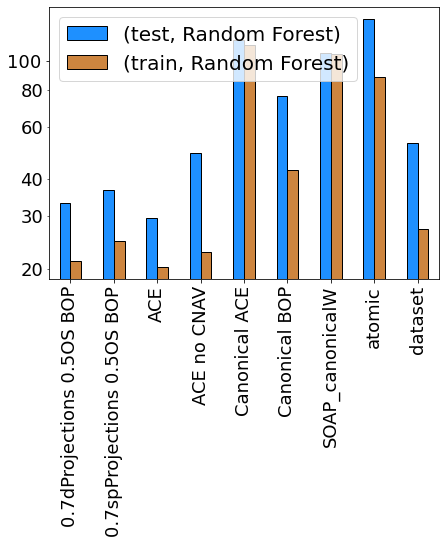

In [95]:
ax = PlotVotedScores.unstack(level=0).sort_index().plot.bar(
    color = ['dodgerblue', 'peru'], edgecolor = 'black'
)#.sort_values(by=('test', ModelName), ascending=False)*1000).plot.bar()
ax.set_yscale('log', subs=[2,3, 4, 6, 8, 10])
ax.get_legend().set_title('')
ax.tick_params(axis='y', which = 'minor')                                                                                                     
ax.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

# Prediction line 

In [97]:
from sklearn.ensemble._voting import VotingRegressor as type_voting_regressor

In [98]:
def get_bag_of_predictions(bag_of_regressors : type_voting_regressor, features_df  : pd.core.frame.DataFrame):
    bag_of_predictions = {}
    for name, regressor_in_bag in enumerate(bag_of_regressors):
        bag_of_predictions[name] = regressor_in_bag.predict(features_df)
        bag_of_predictions [name] = pd.Series(bag_of_predictions[name],name=name,  index=features_df.index)
    return pd.concat(bag_of_predictions, axis=1)
    

In [99]:
predictions={}
stds={}
Prediction = {} 

In [100]:
for name, regressor in voting_regressor.items():
    Prediction[name] = regressor.predict(Features[name[1]])
    Prediction[name] = pd.DataFrame(Prediction[name], index = Features[name[1]].index, columns=[DS.target_name])
    predictions[name] = get_bag_of_predictions(regressor.estimators_, Features[name[1]])
    stds[name] = predictions[name].std(axis=1)

# Predicted BS 

In [101]:
predictedBS = copy.copy(DS.BS.loc[DS.target.index])

In [102]:
for combi, prediction in Prediction.items():
    predictedBS[f'EF_nmhcp_{combi[1]}'] = prediction

In [103]:
predictedBS.filter(regex='EF_nmhcp_*')

,EF_nmhcp,EF_nmhcp_SOAP_canonicalW,EF_nmhcp_atomic,EF_nmhcp_dataset,EF_nmhcp_Canonical ACE,EF_nmhcp_Canonical BOP,EF_nmhcp_ACE no CNAV,EF_nmhcp_ACE,EF_nmhcp_0.7dProjections 0.5OS BOP,EF_nmhcp_0.7spProjections 0.5OS BOP
Fe_pv4Mo_sv20.C36-ABBBB.FM,0.478663,0.359284,0.344879,0.505151,0.378500,0.427678,0.516938,0.509166,0.508544,0.506889
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,0.133919,0.164000,0.298850,0.140961,0.170964,0.166000,0.134439,0.130970,0.139760,0.145026
Fe_pv2Mo_sv11.mu-BBABB.FM,0.403272,0.371520,0.320329,0.421574,0.388282,0.437707,0.413926,0.402697,0.402363,0.402400
Fe_pv8Mo_sv22.sigma-BBBAB.NM,0.058290,0.194422,0.270421,0.078790,0.210133,0.176208,0.058648,0.060251,0.059190,0.052840
Fe_pv2Mo_sv11.mu-BBBBA.NM,0.363607,0.388424,0.320329,0.360792,0.403878,0.381858,0.375799,0.373039,0.366261,0.365388
...,...,...,...,...,...,...,...,...,...,...
Fe_pv8Mo_sv16.C36-BAABB.NM,0.404970,0.363388,0.286563,0.444171,0.386552,0.403905,0.411111,0.406056,0.425501,0.416960
Fe_pv30.sigma.FM,0.075258,0.074327,0.105022,0.116396,0.130557,0.156730,0.069504,0.075209,0.073508,0.075657
Fe_pv6.C15.FM,0.144169,0.149847,0.164169,0.157713,0.211682,0.269074,0.161959,0.161417,0.158000,0.158796
Mo_sv8.A15.NM,0.095306,0.099637,0.372638,0.209803,0.117450,0.094770,0.092061,0.097745,0.116962,0.094307


## save the prediction

In [104]:
#predictedBS.to_pickle(os.path.join(DS.dataset, 'results', f'{DS.dataset}_{ModelName}_PredictedBS.pkl'))


In [116]:
#iwanttoplot = {'atomic':'Matminer',
iwanttoplot = {'dataset': 'atomic+oneHot', test_bop_feature:'Bond specific BOP'}
#iwanttoplot = {'dataset': 'dataset', 'Projections OS BOP':'Projections OS BOP'}

dataset atomic+oneHot
0.7dProjections 0.5OS BOP Bond specific BOP


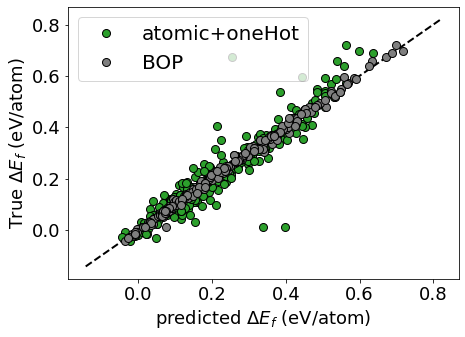

In [117]:
x_y = np.linspace(DS.target.min()-0.1, DS.target.max()+0.1, 2)
fig, ax = plt.subplots()
ax.plot(x_y, x_y, '--k', lw=2)
for name, legend in iwanttoplot.items():
    print(name, legend)
    legend = legend.replace('dataset', 'polyhedra').replace('Bond specific BOP', 'BOP')
    combi = (ModelName, name)
    if combi not in Prediction.keys():
        print(f'{combi} has not been processed yet')
        continue
    ax.plot(Prediction[combi].values, DS.target.values, 'o', markersize=8, markeredgecolor='k', color=colors[name], label=legend, )
ax.set_xlabel(r'predicted $\Delta E_f$ (eV/atom)')
ax.set_ylabel(r'True $\Delta E_f$ (eV/atom)')
ax.legend()
fig.savefig(os.path.join(DS.dataset,'graphs', f'{DS.dataset}_{ModelName}_predictionline_{target_case}.pdf'))

# Recursivity

REDO RECURSIVITY TESTS
 - redefine model
 - refit model

In [118]:
Tester = DatasetTester()

In [119]:
from importlib.machinery import SourceFileLoader
Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
# from Tools.DatasetTools.DatasetOperator import Dataset
# DS = SourceFileLoader('DS', 'Tools/DatasetTools/DatasetOperator.py').load_module().Dataset('Fe-Mo')
# Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
# samplesplit = DS.get_samplesplit()

In [120]:
import copy

In [121]:
RecursivityModels = copy.deepcopy(Models[ModelName])

# Fits on reduced features 

In [122]:
ReducedFittedModels = {}

In [123]:
Reduced_features_fitting_location = os.path.join(DS.resultslocation, f'ReducedFeaturesCVSearch_{target_case}.pkl')

In [124]:
#if os.path.exists(Reduced_features_fitting_location):
#    with open(Reduced_features_fitting_location, 'rb') as pkl:
#        ReducedFittedModels = pickle.load(pkl)

In [125]:
MO.modeloptions

{'Kernel Ridge': {'regressor__alpha': [1.0, 0.1, 0.01],
  'regressor__kernel': ['polynomial'],
  'regressor__degree': [2, 3, 4, 5],
  'regressor__coef0': [0, 1, 2, 3, 4, 5]}}

In [ ]:
maxorders = [8, 10, 12, 14, 16]
for name, model in Models.items():
    if name != ModelName:
        continue
    progress = tqdm(product(Features.items(), maxorders), total=len(maxorders)*len(Features))
    for (key, features), maxorder in progress:  # maxorder in range(4,9):
        progress.set_description(name+', '+key+', '+str(maxorder)+':  ')
        if (name, key, maxorder) in ReducedFittedModels.keys():
            continue
        if 'no CNAV' in key:
            continue
        if 'BOP' not in key:
            continue
        if 'Projections' not in key:
            continue
        if (name, key, maxorder) in ReducedFittedModels.keys():
            continue
        if maxorder < 10:
            regexstr = f'^(?!.*_[{maxorder}-9]_.*|.*_1[0-9]_.*)'
        else:
            regexstr = f'^(?!.*_1[{maxorder - 10}-9]_.*)'
#        for key, features in progress: #Features.items():
        model = GridSearchCV(
            Models[name],
            MO.modeloptions[name], 
            scoring='neg_root_mean_squared_error', 
            cv = 5,#samplefolds,
            return_train_score= True,
        )
        if 'BOP' in key:
            reducedfeatures = features.filter(regex=regexstr)
        else:
            reducedfeatures = features
        ReducedFittedModels[(name, key, maxorder)] = model.fit(reducedfeatures, DS.target)

  0%|          | 0/190 [00:00<?, ?it/s]

In [114]:
with open(Reduced_features_fitting_location, 'wb') as pkl:
    pickle.dump(ReducedFittedModels, pkl)

In [115]:
somecombi = (ModelName, 'Projections BOP')

In [116]:
features_in_reduced = pd.Index(ReducedFittedModels[somecombi+(16,)].feature_names_in_)

In [117]:
best_scores_reduced = collect_best_scores(ReducedFittedModels)

In [118]:
model = best_scores_reduced.index.get_level_values(0)

In [119]:
test_scores_vs_max = best_scores_reduced.unstack().transpose().loc['test'].dropna(axis=1)

In [120]:
full_model_test_scores = best_scores_reduced.unstack().transpose().loc['test']

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


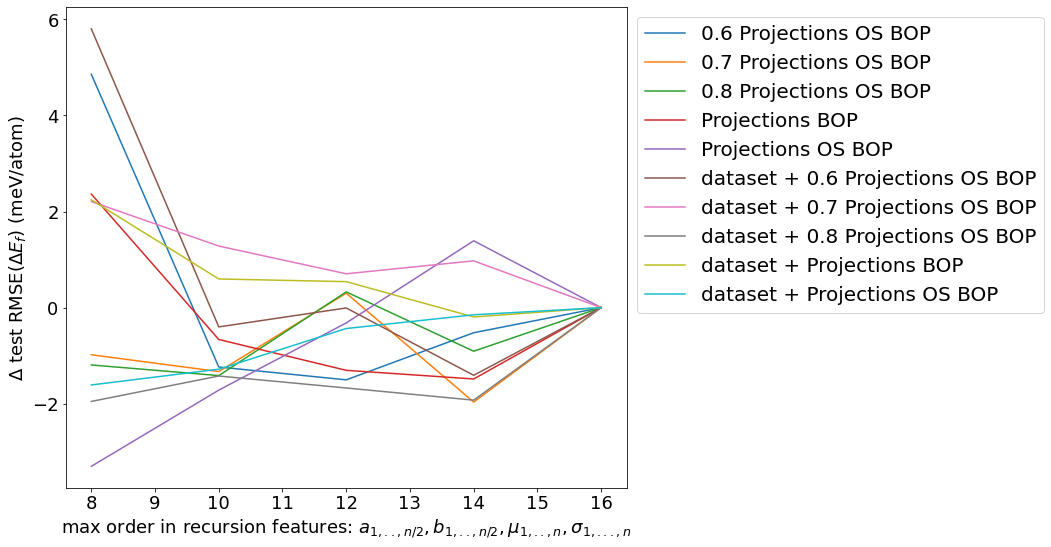

In [121]:
fig, ax = plt.subplots(figsize=(15, 8))
for combi in test_scores_vs_max.columns:
#    if 'BOP' not in combi[1]:
#        continue
#    if 'Canonical' in combi[1]:
#        continue
#    if 'dataset' not in combi[1]:
#        continue
    drmse = (test_scores_vs_max[combi].values - test_scores_vs_max[combi].values[-1])*1000  # - full_model_test_scores[combi[0]][combi[1]]*1000
    l = ax.plot(test_scores_vs_max[combi].index, drmse, label=combi[1])[0]
#    ax.axhline(full_model_test_scores[combi[0]][combi[1]]*1000,ls='--', color=l.get_color())
ax.legend(bbox_to_anchor = (1, 1))
ax.set_ylabel(r'$\Delta$ test RMSE($\Delta E_f$) (meV/atom)')
ax.set_xlabel(r'max order in recursion features: $a_{1,..,n/2}, b_{1,..,n/2}, \mu_{1,..,n}, \sigma_{1,...,n}$')
fig.tight_layout()
fig.savefig(os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_full_recursivity_{target_case}.eps'))

# Feature Importances 

In [122]:
def get_importances(voting_regressor):
    importances = {}
    for combi, estimator in voting_regressor.items():
        print(combi[1])
        X = DS.Features[combi[1]]#[selected]
        allimportances = get_importances(estimator , X,  DS.target)
        importances[combi] =allimportances #  [allimportances['importances_mean']>=allimportances['importances_mean']['random']]
    for (modelname, name),timportances in importances.items():
        timportances.sort_values(by='importances_mean', inplace=True, ascending=False)
    return importances


In [123]:
def plot_importances(importances):
    for name, timp in importances.items():
        fig, ax = plt.subplots(figsize=(12, 8))
        x = timp['importances_mean'][:20]
        sns.barplot(y=timp.index[:20], x=x , ax=ax, color='Purple')
        ylabels = [get_str_formatted(fname) for fname in x.index]
        ax.set_xscale('log')
        ax.set_xlabel('permutation importance')
        ax.set_yticklabels(ylabels, fontsize=12)
        fig.suptitle(name[1].replace('dataset', 'polyhedra'))
        fig.tight_layout()

# Errors by phase by model

In [124]:
train_errors = {}
rmse = {}

In [125]:
absolute_errors = {}

In [126]:
iwanttoseeerrors = ['0.7 Projections OS BOP', 'SOAP_specific', 'ACE']

In [127]:
for combi, thisprediction in Prediction.items(): # voting_regressor.items():
    if 'sOS' in combi[1]:
        continue
    if combi[1] not in iwanttoseeerrors:
        continue
    print(combi)
    absolute_errors[combi] = thisprediction.sub(DS.target, axis=0)
    rmse[combi] = {}
    for phase in DS.BS.Phase.unique():
        thiserrors = absolute_errors[combi][DS.BS.Phase == phase]**2
        rmse[combi][phase] =  np.sqrt(thiserrors.sum()/len(thiserrors)).values[0]
    rmse[combi]['total'] = np.sqrt((thisprediction.sub(DS.target, axis=0)**2/len(thisprediction)).sum(axis=0)).values[0]
    rmse[combi]['test'] = np.sqrt(
        (
            (thisprediction.loc[DS.samplesplit['test']].sub(DS.target[DS.samplesplit['test']], axis=0)**2).sum()/len(DS.samplesplit['test'])
        ).values[0]
    )

('Random Forest', '0.7 Projections OS BOP')
('Random Forest', 'ACE')
('Random Forest', 'SOAP_specific')


In [128]:
rmse

{('Random Forest', '0.7 Projections OS BOP'): {'A15': 0.04065932007136904,
  'C14': 0.024072012014604346,
  'chi': 0.02748080156361513,
  'C36': 0.03448928024856644,
  'sigma': 0.02117800582588039,
  'mu': 0.024444003853197224,
  'C15': 0.034805797174175195,
  'R': 0.032349810426621516,
  'total': 0.02789575020443379,
  'test': 0.0418180178706317},
 ('Random Forest', 'ACE'): {'A15': 0.026327181822355637,
  'C14': 0.020820204883221557,
  'chi': 0.017170957250952436,
  'C36': 0.028122344179399836,
  'sigma': 0.016964956219519867,
  'mu': 0.022238415868759236,
  'C15': 0.047617755648347374,
  'R': 0.033068741061863714,
  'total': 0.023597685017554406,
  'test': 0.03256767650839733},
 ('Random Forest', 'SOAP_specific'): {'A15': 0.0362737657471359,
  'C14': 0.026085699126508897,
  'chi': 0.022264235438111044,
  'C36': 0.035000819858997785,
  'sigma': 0.021238880901419267,
  'mu': 0.023846278673124905,
  'C15': 0.03462489540212195,
  'R': 0.032834831082419524,
  'total': 0.02735945836348265,

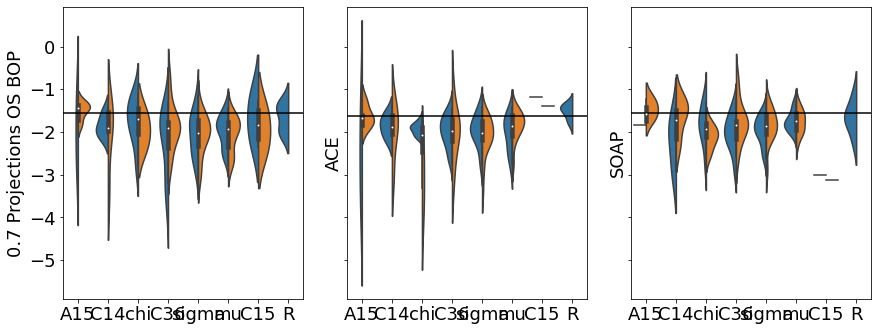

In [129]:
width = plt.rcParams['figure.figsize'][0]*len(iwanttoseeerrors)*(3/5)
height = plt.rcParams['figure.figsize'][1]
fig, axes = plt.subplots(1, len(rmse),sharey=True, figsize=(width, height))
for (combi, thiserrors), ax in zip(absolute_errors.items(), axes):
    sns.violinplot(
        y=absolute_errors[combi][target_case].map(np.log10), 
        x=DS.StructureNames, hue=DS.Features['dataset']['Mag'], split=True, ax=ax
    )
    ax.axhline(np.log10(rmse[combi]['total']),color='k', label='rmse')
    ax.get_legend().remove()
    ax.set_xlabel('')
    ax.set_ylabel(combi[1].replace('_specific', ''))
fig.tight_layout()

In [130]:
rmsedf = pd.DataFrame.from_dict(rmse, orient = 'index')

In [131]:
rmsedf.sort_values(by=(ModelName, '0.7 Projections OS BOP'), axis = 1, inplace=True)

In [132]:
rmsedf.sort_values(by='total', inplace=True)

In [133]:
important = [(ModelName, '0.7 Projections OS BOP'), (ModelName, 'ACE'), (ModelName, 'SOAP_specific')]

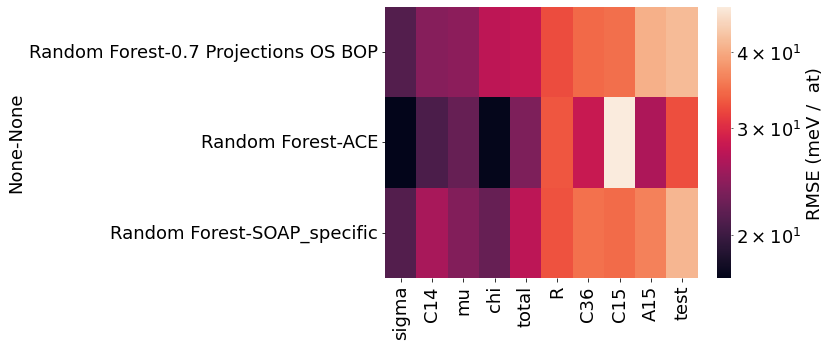

In [134]:
from matplotlib.colors import LogNorm, Normalize
ax = sns.heatmap(rmsedf.loc[important]*1000,  cbar_kws={'label': 'RMSE (meV /  at)'}, norm=LogNorm())